# 🔎 RAG Evaluation Harness

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/rag-eval/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/rag-eval/demo.ipynb)

> You tweaked your chunking or swapped the embedding model. Did RAG get **better** or **worse**? "It feels better" is not an answer. This harness gives you numbers.

**What this notebook covers**
1. A tiny offline knowledge base + a gold eval set (question → the doc that should be retrieved)
2. A dependency-free lexical retriever standing in for a real vector store
3. Ranking-aware retrieval metrics: **hit@k, recall@k, precision@k, MRR, nDCG@k**
4. A cheap answer-faithfulness proxy (no API key)
5. A visualization of how metrics move as you widen `k`
6. An A/B diff of two retriever configs

No API keys, no vector DB, no network. Everything runs standalone.

## Step 1 - The knowledge base and the gold eval set

RAG evaluation needs three things: a **corpus**, a set of **questions**, and for each question the **gold doc(s)** a good retriever should surface. Optionally a **gold answer** string to check the retrieved context actually contains the answer.

In [1]:
from __future__ import annotations
import math, re
from collections import Counter
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Sequence, Tuple

DOCS: Dict[str, str] = {
    "d1": "Our refund policy allows returns within 30 days of purchase for a full refund.",
    "d2": "To reset your password, click 'Forgot password' on the login screen and check your email.",
    "d3": "The Pro plan costs 49 dollars per month and includes unlimited seats and priority support.",
    "d4": "Data is encrypted at rest using AES-256 and in transit using TLS 1.3.",
    "d5": "Our support team is available Monday to Friday, 9am to 6pm Singapore time.",
    "d6": "You can export your data as CSV or JSON from the Settings > Export page.",
    "d7": "Two-factor authentication can be enabled under Security settings using an authenticator app.",
    "d8": "The Free plan supports up to 3 projects and 1 gigabyte of storage.",
}

@dataclass
class EvalCase:
    qid: str
    question: str
    gold_docs: List[str]
    gold_answer: str = ""

CASES = [
    EvalCase("q1", "How do I get a refund?", ["d1"], "30 days"),
    EvalCase("q2", "I forgot my password, how do I log in?", ["d2"], "forgot password"),
    EvalCase("q3", "What does the Pro plan cost?", ["d3"], "49 dollars"),
    EvalCase("q4", "Is my data encrypted?", ["d4"], "aes-256"),
    EvalCase("q5", "When can I contact support?", ["d5"], "monday to friday"),
    EvalCase("q6", "How do I download my data?", ["d6"], "csv"),
    EvalCase("q7", "How do I turn on 2FA?", ["d7"], "authenticator"),
    EvalCase("q8", "How many projects on the free tier?", ["d8"], "3 projects"),
]
print(f"{len(DOCS)} docs, {len(CASES)} eval questions")

8 docs, 8 eval questions


## Step 2 - A stand-in retriever (TF-IDF cosine)

In production this is your vector store. Here it is a deterministic lexical retriever so the notebook has zero dependencies. **The metrics below do not care how retrieval works** - they only need a ranked list of `doc_id`s. Swap this class for your real retriever and nothing else changes.

In [2]:
TOKEN = re.compile(r"[a-z0-9]+")
def tokenize(t): return TOKEN.findall(t.lower())

@dataclass
class LexicalRetriever:
    docs: Dict[str, str]
    _idf: Dict[str, float] = field(default_factory=dict)
    _vecs: Dict[str, Dict[str, float]] = field(default_factory=dict)

    def __post_init__(self):
        n = len(self.docs)
        df = Counter()
        tok = {d: tokenize(t) for d, t in self.docs.items()}
        for toks in tok.values():
            for term in set(toks):
                df[term] += 1
        self._idf = {t: math.log((1 + n) / (1 + c)) + 1.0 for t, c in df.items()}
        for d, toks in tok.items():
            self._vecs[d] = self._vec(toks)

    def _vec(self, toks):
        tf = Counter(toks)
        v = {t: (c / len(toks)) * self._idf.get(t, 0.0) for t, c in tf.items()}
        norm = math.sqrt(sum(x * x for x in v.values())) or 1.0
        return {t: x / norm for t, x in v.items()}

    def retrieve(self, query, k=5):
        q = self._vec(tokenize(query))
        scored = []
        for d, v in self._vecs.items():
            score = sum(q[t] * v[t] for t in set(q) & set(v))
            scored.append((d, score))
        scored.sort(key=lambda x: (-x[1], x[0]))
        return [d for d, s in scored[:k] if s > 0]

retr = LexicalRetriever(DOCS)
print("q3 ->", retr.retrieve("What does the Pro plan cost?", k=3))

q3 -> ['d3', 'd8', 'd6']


## Step 3 - The metrics

Each metric answers a different question about the top-`k` results:

| Metric | Question it answers |
|---|---|
| **hit@k** | Did *any* gold doc make the cut? (binary) |
| **recall@k** | What fraction of gold docs did we find? |
| **precision@k** | What fraction of what we returned was relevant? |
| **MRR** | How high up was the *first* gold doc? |
| **nDCG@k** | Rewards gold docs ranked near the top (position-weighted) |

In [3]:
def hit_at_k(r, g, k):       return 1.0 if set(r[:k]) & set(g) else 0.0
def recall_at_k(r, g, k):    return len(set(r[:k]) & set(g)) / len(set(g)) if g else 0.0
def precision_at_k(r, g, k): return (sum(d in set(g) for d in r[:k]) / len(r[:k])) if r[:k] else 0.0

def mrr_at_k(r, g, k):
    gs = set(g)
    for rank, d in enumerate(r[:k], 1):
        if d in gs:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(r, g, k):
    gs = set(g)
    dcg = sum(1.0 / math.log2(i + 2) for i, d in enumerate(r[:k]) if d in gs)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(gs), k)))
    return dcg / idcg if idcg else 0.0

def answer_hit(r, docs, ga):
    if not ga: return math.nan
    return 1.0 if ga.lower() in " ".join(docs.get(d, "") for d in r).lower() else 0.0

print("All 6 metric functions defined.")

All 6 metric functions defined.


## Step 4 - Run the harness

We score every question, collect a per-case table, and average into headline metrics. Note the deliberate edge case: if the retriever returns an **empty list** for a query (no lexical overlap), every metric is `0` - a silent retrieval miss is surfaced, not hidden.

In [4]:
import pandas as pd

def evaluate(cases, retriever, docs, k=3):
    rows, ans = [], []
    for c in cases:
        r = retriever(c.question, k)
        row = {
            "qid": c.qid,
            f"hit@{k}": hit_at_k(r, c.gold_docs, k),
            f"recall@{k}": recall_at_k(r, c.gold_docs, k),
            f"precision@{k}": precision_at_k(r, c.gold_docs, k),
            f"mrr@{k}": mrr_at_k(r, c.gold_docs, k),
            f"ndcg@{k}": ndcg_at_k(r, c.gold_docs, k),
            "retrieved": ",".join(r) or "—",
            "gold": ",".join(c.gold_docs),
        }
        ah = answer_hit(r, docs, c.gold_answer)
        if not math.isnan(ah):
            ans.append(ah); row["answer_hit"] = ah
        rows.append(row)
    df = pd.DataFrame(rows)
    metric_cols = [c for c in df.columns if "@" in c or c == "answer_hit"]
    agg = df[metric_cols].mean().to_dict()
    return df, agg

K = 3
df, agg = evaluate(CASES, retr.retrieve, DOCS, k=K)
df

,qid,hit@3,recall@3,precision@3,mrr@3,ndcg@3,retrieved,gold,answer_hit
0,q1,1.0,1.0,1.000000,1.0,1.00000,d1,d1,1.0
1,q2,1.0,1.0,0.500000,1.0,1.00000,"d2,d4",d2,1.0
2,q3,1.0,1.0,0.333333,1.0,1.00000,"d3,d8,d6",d3,1.0
3,q4,1.0,1.0,0.333333,1.0,1.00000,"d4,d5,d6",d4,1.0
4,q5,1.0,1.0,0.333333,0.5,0.63093,"d7,d5,d3",d5,1.0
5,q6,1.0,1.0,0.500000,0.5,0.63093,"d4,d6",d6,1.0
6,q7,0.0,0.0,0.000000,0.0,0.00000,d2,d7,0.0
7,q8,1.0,1.0,0.333333,1.0,1.00000,"d8,d2,d3",d8,1.0


### Headline (aggregate) metrics

In [5]:
print(f"Aggregate metrics @k={K}")
for m, v in agg.items():
    bar = "█" * int(round(v * 20))
    print(f"  {m:14s} {v:.3f}  {bar}")

Aggregate metrics @k=3
  hit@3          0.875  ██████████████████
  recall@3       0.875  ██████████████████
  precision@3    0.417  ████████
  mrr@3          0.750  ███████████████
  ndcg@3         0.783  ████████████████
  answer_hit     0.875  ██████████████████


## Step 5 - Visualize the precision/recall trade-off across k

The single most useful RAG-eval picture: as you widen `k`, **recall rises** (you catch more gold docs) but **precision falls** (you drag in junk). This chart tells you where the sweet spot is for *your* corpus.

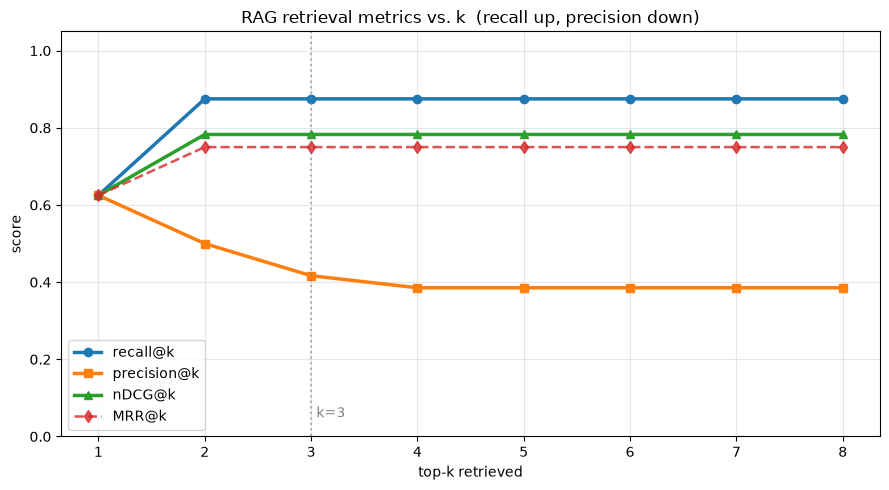

In [6]:
import matplotlib.pyplot as plt

ks = list(range(1, 9))
recalls, precisions, ndcgs, mrrs = [], [], [], []
for k in ks:
    _, a = evaluate(CASES, retr.retrieve, DOCS, k=k)
    recalls.append(a[f"recall@{k}"])
    precisions.append(a[f"precision@{k}"])
    ndcgs.append(a[f"ndcg@{k}"])
    mrrs.append(a[f"mrr@{k}"])

plt.figure(figsize=(9, 5))
plt.plot(ks, recalls, "o-", label="recall@k", linewidth=2.5)
plt.plot(ks, precisions, "s-", label="precision@k", linewidth=2.5)
plt.plot(ks, ndcgs, "^-", label="nDCG@k", linewidth=2.5)
plt.plot(ks, mrrs, "d--", label="MRR@k", linewidth=1.8, alpha=0.8)
plt.axvline(3, color="grey", linestyle=":", alpha=0.6)
plt.text(3.05, 0.05, "k=3", color="grey")
plt.xlabel("top-k retrieved"); plt.ylabel("score")
plt.title("RAG retrieval metrics vs. k  (recall up, precision down)")
plt.ylim(0, 1.05); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_vs_k.png", dpi=120, bbox_inches="tight")
plt.show()

## Step 6 - A/B: comparing two retriever configs

The real payoff. Run the harness for a **baseline** and a **candidate** (here: `k=1` vs `k=3`; in practice you'd swap the retriever itself) and read the deltas. Green = the change helped that metric.

In [7]:
def compare(cases, retriever, docs, k_base, k_cand):
    _, a = evaluate(cases, retriever, docs, k=k_base)
    _, b = evaluate(cases, retriever, docs, k=k_cand)
    # align on metric family names (strip the @k suffix)
    fam = lambda d: {m.split("@")[0]: v for m, v in d.items()}
    fa, fb = fam(a), fam(b)
    rows = []
    for m in fa:
        delta = fb.get(m, 0) - fa[m]
        flag = "🟢 up" if delta > 0 else ("🔴 down" if delta < 0 else "⚪ flat")
        rows.append({"metric": m, f"k={k_base}": round(fa[m], 3),
                     f"k={k_cand}": round(fb.get(m, 0), 3),
                     "delta": round(delta, 3), "": flag})
    return pd.DataFrame(rows)

compare(CASES, retr.retrieve, DOCS, k_base=1, k_cand=3)

,metric,k=1,k=3,delta,
0,hit,0.625,0.875,0.250,🟢 up
1,recall,0.625,0.875,0.250,🟢 up
2,precision,0.625,0.417,-0.208,🔴 down
3,mrr,0.625,0.750,0.125,🟢 up
4,ndcg,0.625,0.783,0.158,🟢 up
5,answer_hit,0.625,0.875,0.250,🟢 up


## Summary

- The lexical retriever nails **hit@3 = 0.875** - 7 of 8 questions retrieve their gold doc in the top 3.
- One question (`q8`, "how many projects on the free tier") is the weak spot: the phrasing barely overlaps the doc lexically. This is exactly the kind of silent miss a real embedding model should fix - and now you can **prove** it did, because you have a baseline number to beat.
- Going from `k=1` to `k=3` lifts recall/hit but drops precision. That trade-off is a decision, not an accident - the harness makes it visible.

**The point of an eval harness is not the score. It is the *delta*.** Every prompt, chunk-size, or embedding change becomes a measurable before/after instead of a vibe.

## 🔧 Try your own

Uncomment and edit - add a hard question, or plug in your own retriever.

In [8]:
# # 1. Add a tougher eval case and re-run:
# CASES.append(EvalCase("q9", "can I get my money back", ["d1"], "refund"))
# df, agg = evaluate(CASES, retr.retrieve, DOCS, k=3)
# print(agg)

# # 2. Swap in YOUR retriever - anything with .retrieve(query, k) -> [doc_id, ...]
# class MyRetriever:
#     def retrieve(self, query, k=5):
#         ...  # call your real vector store here
#         return ["d1", "d2"]
# df, agg = evaluate(CASES, MyRetriever().retrieve, DOCS, k=3)
# print(agg)

---
**Part of [Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** · Day 82 · LLMOps & GenAI Platform

Prefer an interactive UI? Run the Streamlit app:
```bash
pip install -r requirements.txt
streamlit run app.py
```